In [1]:
# --- Create bank_branch_data.csv (8 branches x 4 quarters) ---
import pandas as pd

rows = [
    # branch, region, quarter, total_income_cr, total_expense_cr, npa_cr, loan_book_cr, deposits_cr
    # FY25-Q1
    ["Mumbai","West","FY25-Q1",185,120,6.5,850,900],
    ["Delhi","North","FY25-Q1",170,112,5.8,780,845],
    ["Bengaluru","South","FY25-Q1",160,105,4.9,700,750],
    ["Chennai","South","FY25-Q1",155,101,5.0,690,740],
    ["Kolkata","East","FY25-Q1",142,95,4.2,650,700],
    ["Ahmedabad","West","FY25-Q1",138,92,4.1,630,680],
    ["Pune","West","FY25-Q1",149,97,4.4,675,720],
    ["Jaipur","North","FY25-Q1",130,88,4.0,600,650],
    # FY25-Q2
    ["Mumbai","West","FY25-Q2",191,123,6.6,865,915],
    ["Delhi","North","FY25-Q2",176,114,5.9,790,855],
    ["Bengaluru","South","FY25-Q2",165,107,4.8,710,760],
    ["Chennai","South","FY25-Q2",160,103,4.9,695,745],
    ["Kolkata","East","FY25-Q2",146,96,4.1,655,705],
    ["Ahmedabad","West","FY25-Q2",141,93,4.0,635,685],
    ["Pune","West","FY25-Q2",152,98,4.3,680,725],
    ["Jaipur","North","FY25-Q2",133,89,3.9,605,655],
    # FY25-Q3
    ["Mumbai","West","FY25-Q3",198,126,6.7,880,925],
    ["Delhi","North","FY25-Q3",182,116,5.9,800,865],
    ["Bengaluru","South","FY25-Q3",171,109,4.7,720,770],
    ["Chennai","South","FY25-Q3",165,104,4.8,700,750],
    ["Kolkata","East","FY25-Q3",150,97,4.1,658,708],
    ["Ahmedabad","West","FY25-Q3",145,94,4.0,640,690],
    ["Pune","West","FY25-Q3",156,100,4.2,685,730],
    ["Jaipur","North","FY25-Q3",136,90,3.9,608,658],
    # FY25-Q4
    ["Mumbai","West","FY25-Q4",205,129,6.6,895,940],
    ["Delhi","North","FY25-Q4",188,118,5.8,812,875],
    ["Bengaluru","South","FY25-Q4",176,111,4.6,732,781],
    ["Chennai","South","FY25-Q4",170,106,4.7,707,755],
    ["Kolkata","East","FY25-Q4",154,99,4.0,662,712],
    ["Ahmedabad","West","FY25-Q4",148,95,3.9,646,695],
    ["Pune","West","FY25-Q4",160,101,4.1,690,735],
    ["Jaipur","North","FY25-Q4",139,91,3.8,612,662],
]

cols = ["branch","region","quarter","total_income_cr","total_expense_cr","npa_cr","loan_book_cr","deposits_cr"]
df = pd.DataFrame(rows, columns=cols)
df.to_csv("bank_branch_data.csv", index=False)
print("✅ Saved bank_branch_data.csv with shape:", df.shape)
print(df.head(), "\n...\n", df.tail())

✅ Saved bank_branch_data.csv with shape: (32, 8)
      branch region  quarter  total_income_cr  total_expense_cr  npa_cr  \
0     Mumbai   West  FY25-Q1              185               120     6.5   
1      Delhi  North  FY25-Q1              170               112     5.8   
2  Bengaluru  South  FY25-Q1              160               105     4.9   
3    Chennai  South  FY25-Q1              155               101     5.0   
4    Kolkata   East  FY25-Q1              142                95     4.2   

   loan_book_cr  deposits_cr  
0           850          900  
1           780          845  
2           700          750  
3           690          740  
4           650          700   
...
        branch region  quarter  total_income_cr  total_expense_cr  npa_cr  \
27    Chennai  South  FY25-Q4              170               106     4.7   
28    Kolkata   East  FY25-Q4              154                99     4.0   
29  Ahmedabad   West  FY25-Q4              148                95     3.9   
30  

In [2]:
import pandas as pd, numpy as np, sqlite3, matplotlib.pyplot as plt

df = pd.read_csv("bank_branch_data.csv")
df.head()

,branch,region,quarter,total_income_cr,total_expense_cr,npa_cr,loan_book_cr,deposits_cr
0,Mumbai,West,FY25-Q1,185,120,6.5,850,900
1,Delhi,North,FY25-Q1,170,112,5.8,780,845
2,Bengaluru,South,FY25-Q1,160,105,4.9,700,750
3,Chennai,South,FY25-Q1,155,101,5.0,690,740
4,Kolkata,East,FY25-Q1,142,95,4.2,650,700


In [3]:
conn = sqlite3.connect(":memory:")
df.to_sql("branches", conn, index=False, if_exists="replace")

pd.read_sql_query("""
SELECT region, COUNT(*) AS num_branches
FROM branches
GROUP BY region
ORDER BY num_branches DESC
""", conn)

,region,num_branches
0,West,12
1,South,8
2,North,8
3,East,4


In [4]:
df["profit_cr"] = df["total_income_cr"] - df["total_expense_cr"]
df["profit_margin_%"] = df["profit_cr"] / df["total_income_cr"] * 100
df["npa_ratio_%"] = df["npa_cr"] / df["loan_book_cr"] * 100
df["loan_to_deposit_%"] = df["loan_book_cr"] / df["deposits_cr"] * 100
df.round(2).head()

,branch,region,quarter,total_income_cr,total_expense_cr,npa_cr,loan_book_cr,deposits_cr,profit_cr,profit_margin_%,npa_ratio_%,loan_to_deposit_%
0,Mumbai,West,FY25-Q1,185,120,6.5,850,900,65,35.14,0.76,94.44
1,Delhi,North,FY25-Q1,170,112,5.8,780,845,58,34.12,0.74,92.31
2,Bengaluru,South,FY25-Q1,160,105,4.9,700,750,55,34.38,0.70,93.33
3,Chennai,South,FY25-Q1,155,101,5.0,690,740,54,34.84,0.72,93.24
4,Kolkata,East,FY25-Q1,142,95,4.2,650,700,47,33.10,0.65,92.86


In [5]:
# pick latest quarter dynamically
latest_q = df["quarter"].sort_values().iloc[-1]
df_q = df[df["quarter"] == latest_q].copy()
latest_q, df_q.shape

('FY25-Q4', (8, 12))

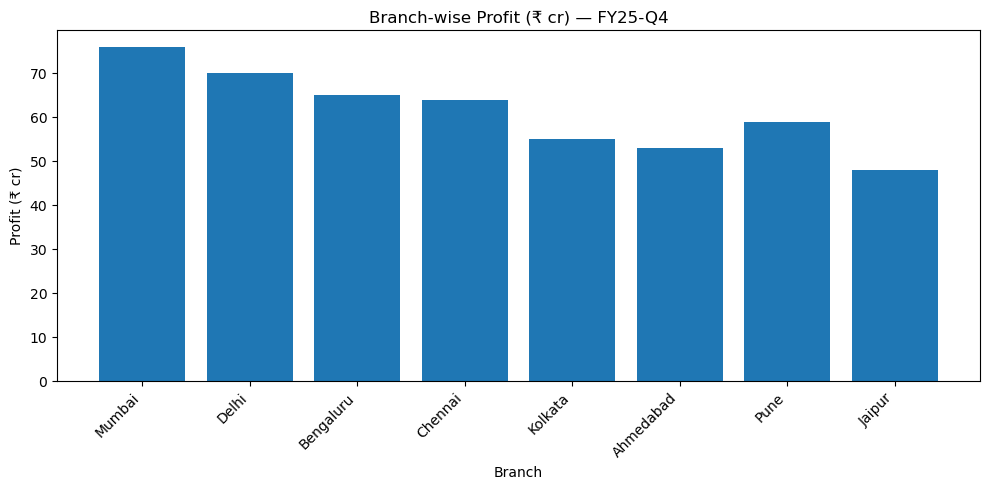

In [6]:
plt.figure(figsize=(10,5))
plt.bar(df_q["branch"], df_q["profit_cr"])
plt.title(f"Branch-wise Profit (₹ cr) — {latest_q}")
plt.xlabel("Branch"); plt.ylabel("Profit (₹ cr)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

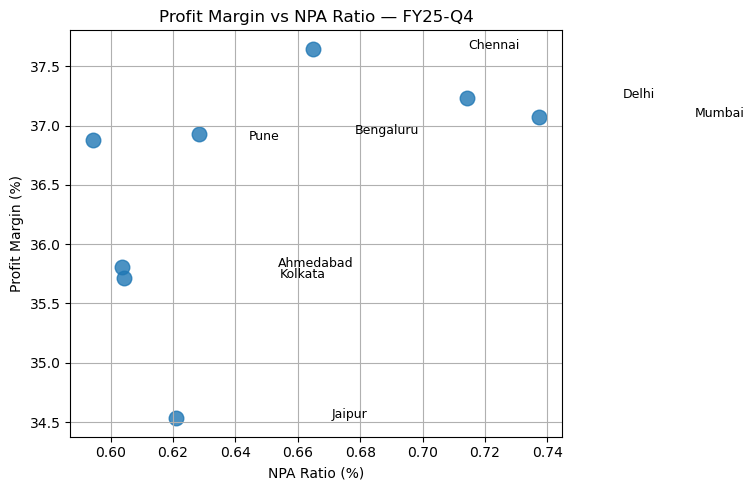

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(df_q["npa_ratio_%"], df_q["profit_margin_%"], s=110, alpha=0.8)
for _, r in df_q.iterrows():
    plt.text(r["npa_ratio_%"]+0.05, r["profit_margin_%"], r["branch"], fontsize=9)
plt.title(f"Profit Margin vs NPA Ratio — {latest_q}")
plt.xlabel("NPA Ratio (%)"); plt.ylabel("Profit Margin (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

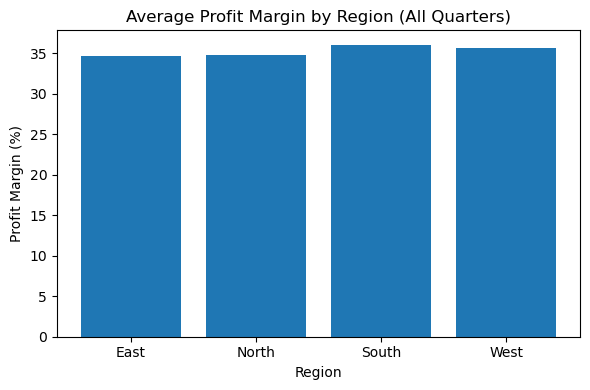

,region,profit_cr,total_income_cr,profit_margin_%
0,East,205,592,34.63
1,North,436,1254,34.77
2,South,476,1322,36.01
3,West,700,1968,35.57


In [8]:
region_perf = df.groupby("region", as_index=False).agg(
    profit_cr=("profit_cr","sum"),
    total_income_cr=("total_income_cr","sum")
)
region_perf["profit_margin_%"] = region_perf["profit_cr"]/region_perf["total_income_cr"]*100

plt.figure(figsize=(6,4))
plt.bar(region_perf["region"], region_perf["profit_margin_%"])
plt.title("Average Profit Margin by Region (All Quarters)")
plt.xlabel("Region"); plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

region_perf.round(2)

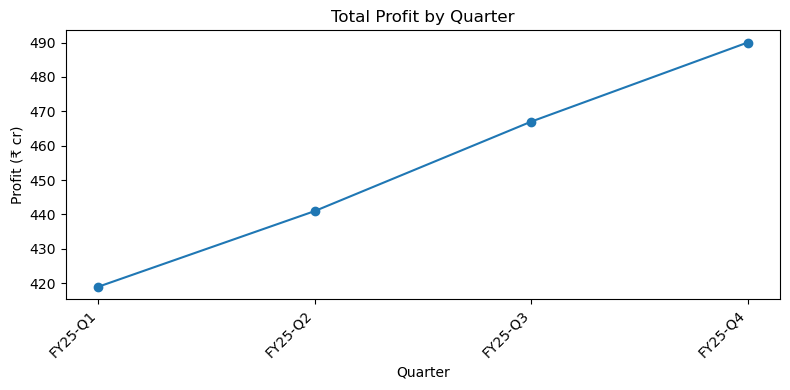

,quarter,profit_cr
0,FY25-Q1,419
1,FY25-Q2,441
2,FY25-Q3,467
3,FY25-Q4,490


In [9]:
by_quarter = df.groupby("quarter", as_index=False)["profit_cr"].sum().sort_values("quarter")
plt.figure(figsize=(8,4))
plt.plot(by_quarter["quarter"], by_quarter["profit_cr"], marker="o")
plt.title("Total Profit by Quarter")
plt.xlabel("Quarter"); plt.ylabel("Profit (₹ cr)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

by_quarter

In [10]:
summary = df[["branch","region","quarter","profit_cr","profit_margin_%","npa_ratio_%","loan_to_deposit_%"]].round(2)
summary.to_csv("branch_summary.csv", index=False)
print("✅ Saved branch_summary.csv")
summary.head()

✅ Saved branch_summary.csv


,branch,region,quarter,profit_cr,profit_margin_%,npa_ratio_%,loan_to_deposit_%
0,Mumbai,West,FY25-Q1,65,35.14,0.76,94.44
1,Delhi,North,FY25-Q1,58,34.12,0.74,92.31
2,Bengaluru,South,FY25-Q1,55,34.38,0.70,93.33
3,Chennai,South,FY25-Q1,54,34.84,0.72,93.24
4,Kolkata,East,FY25-Q1,47,33.10,0.65,92.86
